<a href="https://colab.research.google.com/github/alanchan30/320-project-spring-2026/blob/main/320_project_spring_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Examining how the NBA has evolved over time**<br>
**Spring 2026**<br>
**Alan Chan, Peter Donarum, Ryan Li, Vedansh Tandon, Mason Pan**<br><br>
**Contributions**


*   Project Idea: We collectively decided as a group to do this project idea due to our shared interests in basketball
*   Dataset Curation and Preprocessing: Alan and Peter worked on the data preprocessing, cleaning the data and creating features (PPG, RPG, APG, MPG).
*   Data Exploration and Summary Statistics: Ryan did the first hypothesis testing, examining the difference between the mean points per game during the regular season and the playoffs. Vedansh did the second analysis, Pearson's Correlation Coefficient, looking at the correlation between a player's height and the number of rebounds they get per minute. Mason did the third analysis (ANOVA), analyzing the difference between the mean PPG between all of the NBA 5 year eras.
*   ML Algorithm Design/Development: Alan and Ryan decided what model was best fit for the dataset and what we were trying to learn. After we decided to use the Random Forest model, we chose to compare 2 eras (1999-2009, 2010-2020) because 5 year eras made it difficult to analyze statistically signficant differences.
*   ML Algorithm Training and Test Data Analysis: Vedansh, Peter, and Mason worked on the code to train and test the model, looking to maximize recall, precision, f1-score, and overall accuracy.
*   Visualization, Result Analysis, Conclusion: As a group, we analyzed the results of our model predictions through statistical findings and graphs. We then wrote down our findings in a few paragraphs.
*   Final Tutorial Report Creation: We collectively did this as a group and uploaded everything to GitHub together.



**Why we chose this data set?**<br>
Basketball has gone through a big transformation over the past few decades, especially in how the game is played. All of us grew up watching basketball, so we thought it would be interesting to analyze how the game of basketball has evolved over the years. Given that we now have the resources to analyze data on how the NBA has evolved over the past couple of decades, we can create clear, useful plots and visualizations that help us understand it easily. Answering these questions matters because it clarifies how basketball has changed, helping basketball fans understand and appreciate the different eras of the sport. For coaches and players in professional basketball, this can help them understand long-term trends in basketball that can be applied to future strategies. In this analysis, we aim to tell a historical story of professional basketball by combining data analysis, hypothesis testing, and machine learning, highlighting the key differences between different basketball eras.


# **Data Curation**

**Dataset Link**<br>
https://www.kaggle.com/code/alperendes/nba-analysis-how-basketball-has-changed/input <br>
This dataset conatins the last twenty years of data in major basketball leagues around the world. Some of the important features we used were Total Minutes, Three Pointers Made, Total Assists, True Shooting Percentage, weight, height, and Total Rebounds. However, in this analysis, we only focused on the National Basketball League (NBA).

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import tukey_hsd
import os

In [ ]:
path = kagglehub.dataset_download("jacobbaruch/basketball-players-stats-per-season-49-leagues")

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

df = pd.read_csv(os.path.join(path, "players_stats_by_season_full_details.csv"))

Using Colab cache for faster access to the 'basketball-players-stats-per-season-49-leagues' dataset.
/kaggle/input/basketball-players-stats-per-season-49-leagues/players_stats_by_season_full_details.csv


In [ ]:
df = df[df['League'] == 'NBA']
df = df.dropna()

In [ ]:
df['PPG'] = df['PTS'] / df['GP']
df['RPG'] = df['REB'] / df['GP']
df['APG'] = df['AST'] / df['GP']
df['MPG'] = df['MIN'] / df['GP']

df

,League,Season,Stage,Player,Team,GP,MIN,FGM,FGA,3PM,...,weight_kg,nationality,high_school,draft_round,draft_pick,draft_team,PPG,RPG,APG,MPG
0,NBA,1999 - 2000,Regular_Season,Shaquille O'Neal,LAL,79,3163.0,956,1665,0,...,147.0,United States,Robert G. Cole High School,1.0,1.0,Orlando Magic,29.670886,13.645570,3.784810,40.037975
1,NBA,1999 - 2000,Regular_Season,Vince Carter,TOR,82,3126.0,788,1696,95,...,100.0,United States,Mainland High School,1.0,5.0,Golden State Warriors,25.695122,5.804878,3.926829,38.121951
2,NBA,1999 - 2000,Regular_Season,Karl Malone,UTA,82,2947.0,752,1476,2,...,120.0,United States,Summerfield High School,1.0,13.0,Utah Jazz,25.548780,9.500000,3.707317,35.939024
3,NBA,1999 - 2000,Regular_Season,Allen Iverson,PHI,70,2853.0,729,1733,89,...,75.0,United States,Bethel High School,1.0,1.0,Philadelphia Sixers,28.414286,3.814286,4.685714,40.757143
4,NBA,1999 - 2000,Regular_Season,Gary Payton,SEA,82,3425.0,747,1666,177,...,82.0,United States,Skyline High School,1.0,2.0,Seattle SuperSonics,24.170732,6.451220,8.926829,41.768293
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52110,NBA,2019 - 2020,Playoffs,Nerlens Noel,OKC,7,97.2,8,17,0,...,100.0,United States,Tilton School,1.0,6.0,New Orleans Pelicans,3.000000,4.142857,0.428571,13.885714
52111,NBA,2019 - 2020,Playoffs,Wesley Iwundu,ORL,5,75.8,6,20,4,...,88.0,United States,Spring Westfield High School,2.0,3.0,Orlando Magic,4.200000,2.200000,0.800000,15.160000
52112,NBA,2019 - 2020,Playoffs,Semi Ojeleye,BOS,13,122.2,7,28,5,...,109.0,United States,Ottawa High School,2.0,7.0,Boston Celtics,1.615385,0.923077,0.076923,9.400000
52113,NBA,2019 - 2020,Playoffs,J.R. Smith,LAL,10,74.9,7,26,6,...,102.0,United States,Saint Benedict's Preparatory School,1.0,18.0,New Orleans Pelicans,2.000000,0.300000,0.300000,7.490000


# **Exploratory data analysis**

# First Analysis (Hypothesis Testing):

**Hypothesis:**

$H_0$ = There is no difference between the mean points per game during the regular season and the playoffs

$H_A$ = There is a difference between the mean points per game during the regular season and the playoffs

Significance level ($\alpha$) = 0.05

We are separating the dataset into the statistics from the regular season and the statistics from the playoffs. From there, we plot the scoring distributions for regular season vs. playoffs.

T-Statistic: 3.71
P-Value: 2.13e-04


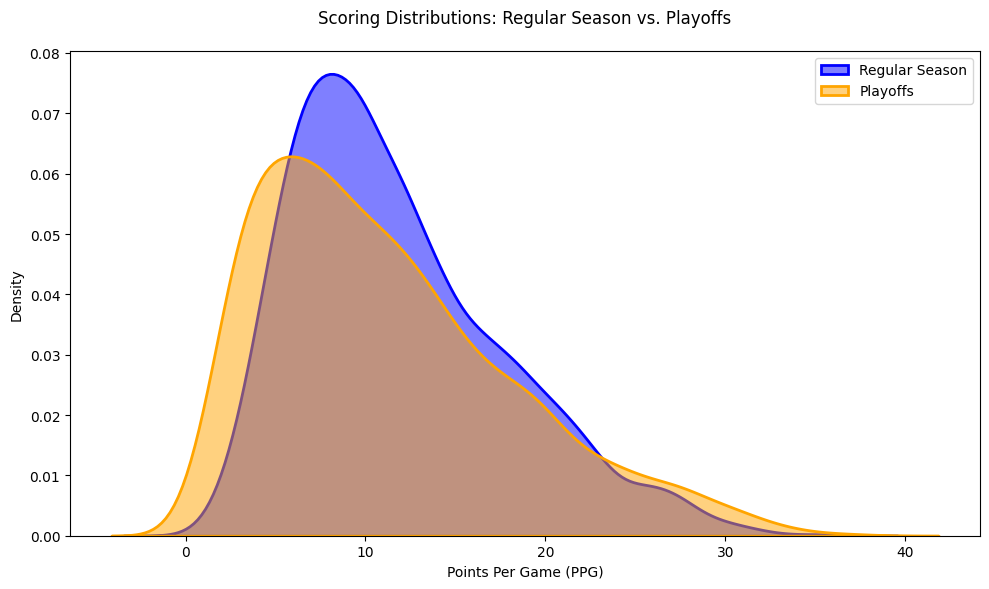

In [ ]:
regular_season = df[df['Stage'] == 'Regular_Season']['PPG'].dropna()
playoffs = df[df['Stage'] == 'Playoffs']['PPG'].dropna()

t_stat, p_val = stats.ttest_ind(regular_season, playoffs, equal_var=False)

print(f"T-Statistic: {t_stat:.2f}")
print(f"P-Value: {p_val:.2e}")

plt.figure(figsize=(10, 6))
sns.kdeplot(regular_season, label='Regular Season', fill=True, alpha=0.5, color='blue', linewidth=2)
sns.kdeplot(playoffs, label='Playoffs', fill=True, alpha=0.5, color='orange', linewidth=2)
plt.title('Scoring Distributions: Regular Season vs. Playoffs', pad=20)
plt.xlabel('Points Per Game (PPG)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

**Conclusion:**

Our p-value for this t-test is 5.76e-05 which is less than $\alpha = 0.05$. So we reject the null hypothesis, suggesting that there is a difference between the points per game of the regular season and the playoffs.


# Second Analysis (Pearson's Correlation Coefficient):

**Question:**

Does a player's height have a correlation with the number of rebounds they get per minute?


**Hypothesis:**

$H_0$ = There is no correlation between a player's height and the number of rebounds they get per minute

$H_A$ = There is a correlation between a player's height and the number of rebounds they get per minute

Significance level ($\alpha$) = 0.05

We are isolating the dataset into the number of rebounds a player gets based on their height. Then, we are plotting it and looking at whether or not they are correlated.

Pearson's r: 0.7091
P-Value: 0.00e+00
Sample Size (N): 6100


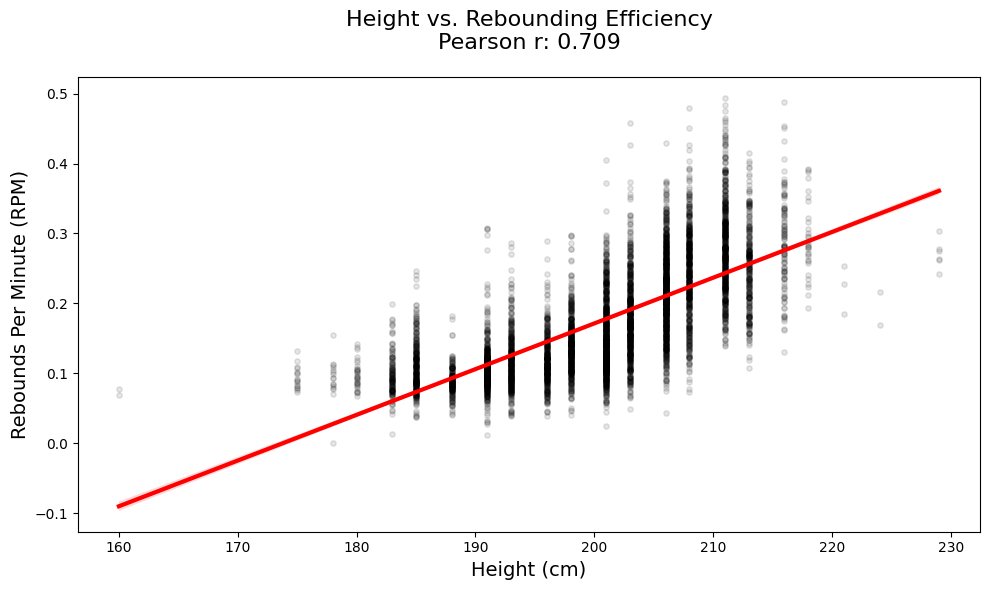

In [ ]:
df_valid = df[df['MIN'] > 0].copy()

df_valid['RPM'] = df_valid['REB'] / df_valid['MIN']

df_corr = df_valid[['height_cm', 'RPM']].dropna()

r_stat, p_val = stats.pearsonr(df_corr['height_cm'], df_corr['RPM'])

print(f"Pearson's r: {r_stat:.4f}")
print(f"P-Value: {p_val:.2e}")
print(f"Sample Size (N): {len(df_corr)}")

plt.figure(figsize=(10, 6))

sns.regplot(
    x='height_cm',
    y='RPM',
    data=df_corr,
    scatter_kws={'alpha': 0.1, 'color': 'black', 's': 15},
    line_kws={'color': 'red', 'linewidth': 3}
)

plt.title(f"Height vs. Rebounding Efficiency\nPearson r: {r_stat:.3f}", pad=20, fontsize=16)
plt.xlabel("Height (cm)", fontsize=14)
plt.ylabel("Rebounds Per Minute (RPM)", fontsize=14)
plt.tight_layout()
plt.show()


**Conclusion:**

The Pearson's Correlation Coefficient is r=0.709, which means the test showed a strong positive correlation. Since the p-value is practically 0, the relationship is highly statistically significant. This confirms that as a player's height increases, their ability to secure rebounds per minute spent on the floor increases. Restricting the data to rebounds per minute instead of rebounds per game allows us to minimize the influence of confounding variables.

# Third Analysis (ANOVA):

**Question:**

Has the offensive output (PPG) of the NBA's elite scorers increased significantly when grouped into 5-year eras over the last two decades?


**Hypothesis:**

$H_0$ = There is no difference between the mean PPG between all of the NBA 5 year eras (1999-2003, 2004-2008, 2009-2013, 2014-2019)

$H_A$ = There is difference between the mean PPG between at least one of the NBA 5 year eras (1999-2003, 2004-2008, 2009-2013, 2014-2019)

Significance level ($\alpha$) = 0.05

We are separating the dataset into 4 eras, each in 5-year intervals. From there, we group them into the top 50 scorers in each era, and are plotting the points per game that they have.

ANOVA F-Statistic: 6.44
ANOVA P-Value: 2.53e-04


/tmp/ipykernel_3822/2350391873.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


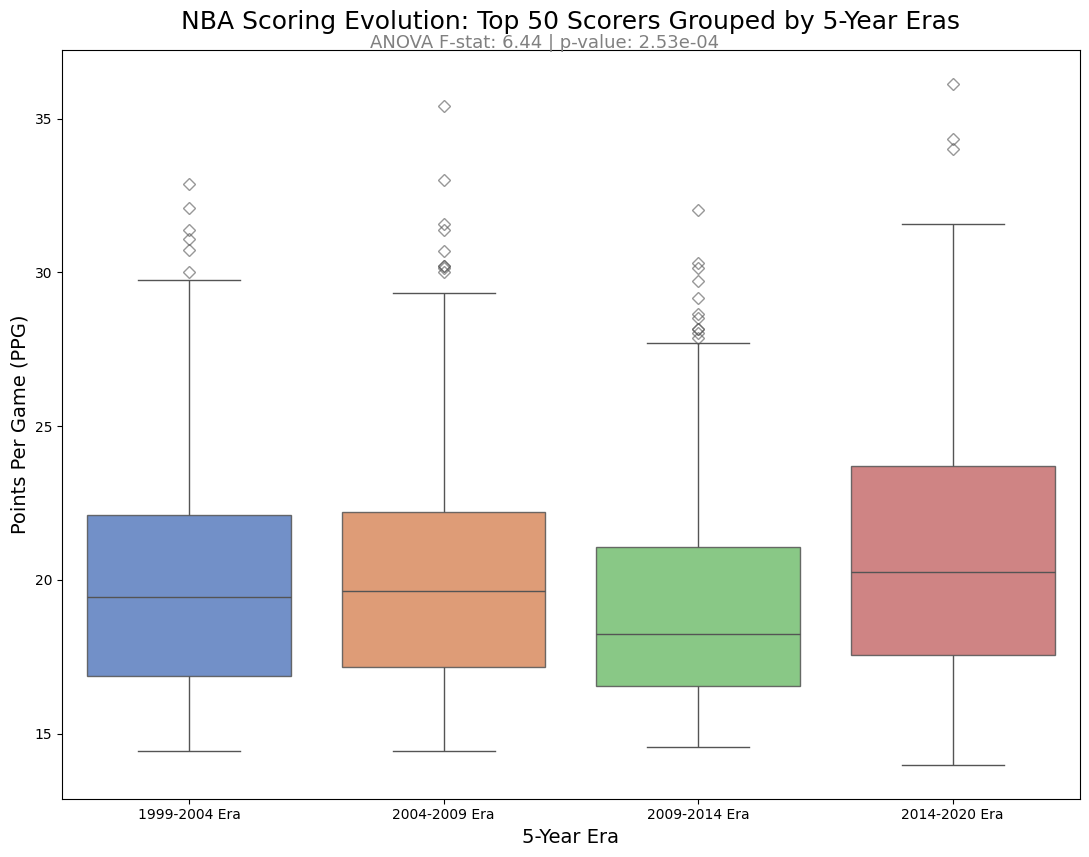


Tukey's HSD Pairwise Group Comparisons (Alpha = 0.05):
--------------------------------------------------
Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.405     0.676    -1.335     0.524
 (0 - 2)      0.578     0.379    -0.352     1.508
 (0 - 3)     -0.892     0.049    -1.782    -0.002
 (1 - 0)      0.405     0.676    -0.524     1.335
 (1 - 2)      0.984     0.033     0.054     1.913
 (1 - 3)     -0.487     0.495    -1.377     0.403
 (2 - 0)     -0.578     0.379    -1.508     0.352
 (2 - 1)     -0.984     0.033    -1.913    -0.054
 (2 - 3)     -1.470     0.000    -2.360    -0.580
 (3 - 0)      0.892     0.049     0.002     1.782
 (3 - 1)      0.487     0.495    -0.403     1.377
 (3 - 2)      1.470     0.000     0.580     2.360



In [ ]:
df_nba = df[df['GP'] >= 20].copy()

df_nba['Start_Year'] = df_nba['Season'].apply(lambda x: int(str(x).split(' - ')[0]))

def assign_5yr_era(year):
    if 1999 <= year <= 2003:
        return '1999-2004 Era'
    elif 2004 <= year <= 2008:
        return '2004-2009 Era'
    elif 2009 <= year <= 2013:
        return '2009-2014 Era'
    elif 2014 <= year <= 2019:
        return '2014-2020 Era'
    else:
        return None

df_nba['5_Year_Era'] = df_nba['Start_Year'].apply(assign_5yr_era)
df_nba = df_nba.dropna(subset=['5_Year_Era'])

top50_dfs = []
for season in df_nba['Season'].unique():
    season_data = df_nba[df_nba['Season'] == season]
    top_50 = season_data.nlargest(50, 'PPG')
    top50_dfs.append(top_50)

df_top50_eras = pd.concat(top50_dfs)

eras = ['1999-2004 Era', '2004-2009 Era', '2009-2014 Era', '2014-2020 Era']
groups = [df_top50_eras[df_top50_eras['5_Year_Era'] == era]['PPG'].dropna() for era in eras]
f_stat, p_val = stats.f_oneway(*groups)

print(f"ANOVA F-Statistic: {f_stat:.2f}")
print(f"ANOVA P-Value: {p_val:.2e}")

plt.figure(figsize=(11, 9))

sns.boxplot(
    x='5_Year_Era',
    y='PPG',
    data=df_top50_eras,
    order=eras,
    palette='muted',
    boxprops=dict(alpha=0.85),
    flierprops=dict(marker='D', markersize=6, alpha=0.6)
)

plt.title("NBA Scoring Evolution: Top 50 Scorers Grouped by 5-Year Eras", pad=15, fontsize=18)
plt.suptitle(f"ANOVA F-stat: {f_stat:.2f} | p-value: {p_val:.2e}", fontsize=13, y=0.92, color='gray')
plt.xlabel("5-Year Era", fontsize=14)
plt.ylabel("Points Per Game (PPG)", fontsize=14)
plt.tight_layout()
plt.show()


res = tukey_hsd(*groups)

print("\nTukey's HSD Pairwise Group Comparisons (Alpha = 0.05):")
print("-" * 50)
# Group indices: 0 = 1999-2004, 1 = 2004-2009, 2 = 2009-2014, 3 = 2014-2020
print(res)

**Conclusion:**

Using the One-Way ANOVA ($\alpha = 0.05$), we found that there was significant difference in the Points Per Game of the league's top 50 scorers across different 5-year eras, with the p-value being less than 0.05. After the ANOVA Test, we performed a Tukey’s HSD post-hoc test to examine the pairwise differences. The Tukey post-hoc test revealed that scoring in the early 2000s (1999-2004) was not statistically different from the late 2000s, with the p-value being 0.23. However, the modern 2014-2020 era showed a lot of statistical differences when compared to both the 1999-2004 era ($p = 0.021$) and the 2009-2014 era ($p < 0.001$). These tests showed that the modern NBA scoring increased dramatically in comparison to the earlier eras, rather than a slow, continuous gradual increase over 20 years.

# **Primary Analysis**

**Why did we choose a random forest classifier?**

To prove that the NBA has truly evolved throughout time, we need to show that the play style in the past is statistically different from the style of play today. By using classification, we are able to test whether a machine learning model is able to take a look at a player's statistics and accurately predict which era they played in. If it is able to do that, then that is quantitative proof that the game has evolved.



We chose a Random Forest Classifier for 3 reasons:

1) There is feature importance, where it is able to tell us not just if the game evolved, but also how it evolved by highlighting specific metrics from different generations

2) It has the ability to handle complex relationships, which apply to basketball, as statistics within basketball are highly connected, such as having higher field goal attempts is related to having higher points per game. Since this is a non-linear model, it is able to handle these relationships much better than linear models that are much simpler.

3) It is pretty robust to outliers, as the NBA always has some players that are extremely unique, such as Shaquille O'Neal's ability to dominate in the early 2000s or Steph Curry's massive 3-point volume in the late 2010s. Since random forests use multiple decision trees, it is able to prevent these extreme statistical outliers from heavily skewing the model's understanding of an era.

We are splitting the dataset into 2 eras and removing eras from the dataset so we can train it. Then, by using multiple features, we are training the machine learning model and evaluating it to see how accurate it is at predicting the era the player was in based on the statistics.

In [ ]:
def assign_2_eras(year):
    if 1999 <= year <= 2009:
        return 'Old Era (1999-2009)'
    elif 2010 <= year <= 2020:
        return 'Modern Era (2010-2020)'
    return None

df_nba['Era'] = df_nba['Start_Year'].apply(assign_2_eras)
df_nba = df_nba.dropna(subset=['Era'])

In [ ]:
df_nba['3PA_PG'] = df_nba['3PA'] / df_nba['GP']
df_nba['3P_Rate'] = df_nba['3PA'] / df_nba['FGA'].replace(0, 1)
df_nba['AST_TOV'] = df_nba['AST'] / df_nba['TOV'].replace(0, 1)
df_nba['True_Shooting_Attempts'] = df_nba['FGA'] + 0.44 * df_nba['FTA']
df_nba['TS_Percent'] = df_nba['PTS'] / (2 * df_nba['True_Shooting_Attempts'].replace(0, 1))

In [ ]:
features = ['PPG', 'RPG', 'APG', '3PA_PG', '3P_Rate', 'TS_Percent', 'AST_TOV', 'height_cm', 'weight_kg']

df_model = df_nba.dropna(subset=features + ['Era'])

X = df_model[features]
y = df_model['Era']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("2-Era Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

2-Era Accuracy: 0.708

Classification Report:
                         precision    recall  f1-score   support

Modern Era (2010-2020)       0.69      0.72      0.70       381
   Old Era (1999-2009)       0.73      0.70      0.71       414

              accuracy                           0.71       795
             macro avg       0.71      0.71      0.71       795
          weighted avg       0.71      0.71      0.71       795



# **Visualization**

/tmp/ipykernel_3822/10340670.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=importances.index, palette='magma')


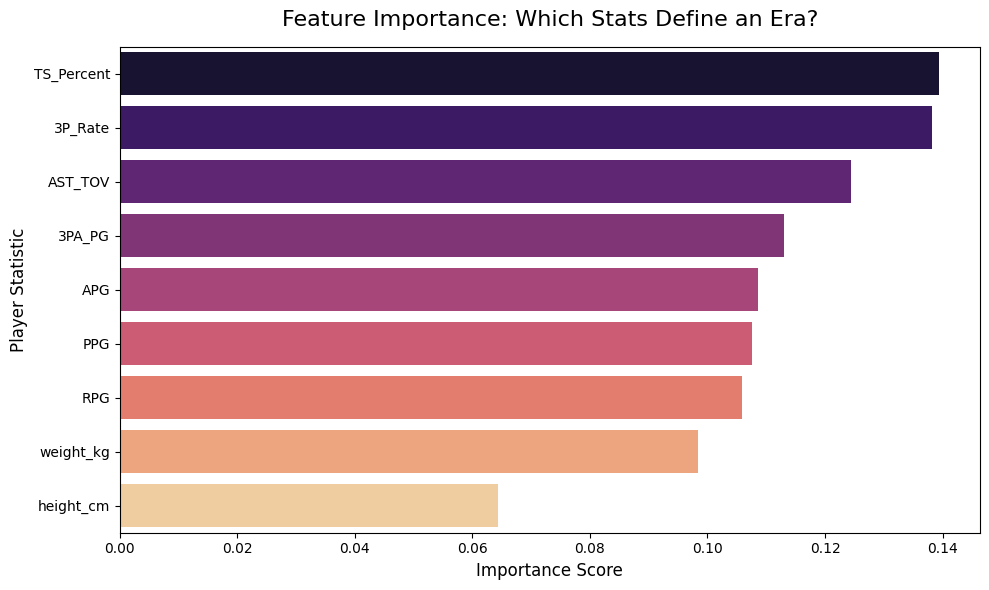

In [ ]:
plt.figure(figsize=(10, 6))

importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
sns.barplot(x=importances, y=importances.index, palette='magma')

plt.title('Feature Importance: Which Stats Define an Era?', pad=15, fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Player Statistic', fontsize=12)
plt.tight_layout()
plt.show()

This chart of feature importance aims to identify which statistics have shown the most evolution in the NBA going from the 2000s to the 2010s. Based on the results we can see that True Shooting Percentage and 3 Point Rate are more important than the normal counting stats like Points, Rebounds, and Assists when trying to identify the era a player is from. This shows how the normal stats have remained relatively unchanged over the years but the way in which players score has changed to favor the harder but more efficient 3-point shot.

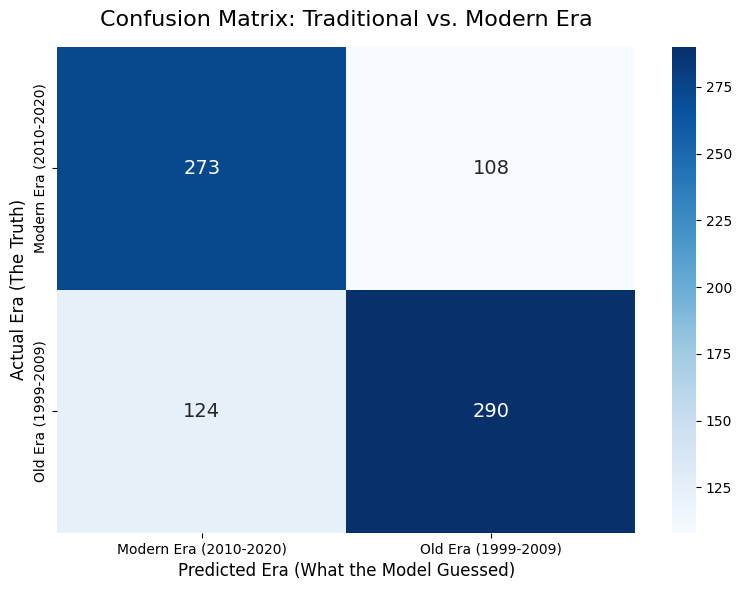

In [ ]:
plt.figure(figsize=(8, 6))

cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_,
            annot_kws={"size": 14})

plt.title('Confusion Matrix: Traditional vs. Modern Era', pad=15, fontsize=16)
plt.xlabel('Predicted Era (What the Model Guessed)', fontsize=12)
plt.ylabel('Actual Era (The Truth)', fontsize=12)
plt.tight_layout()
plt.show()

The confusion matrix visualizes how the model performed when identifying which era a player came from. It shows how the model wasnt perfect and how players can be seen as ahead of their time if they were better 3 Point Shooters in the 2000s and how this could easily lead them to be placed into the modern era. This is also the case for modern day players who focus more on scoring closer to the basket as this style of play reflects the 2000s era of the NBA.

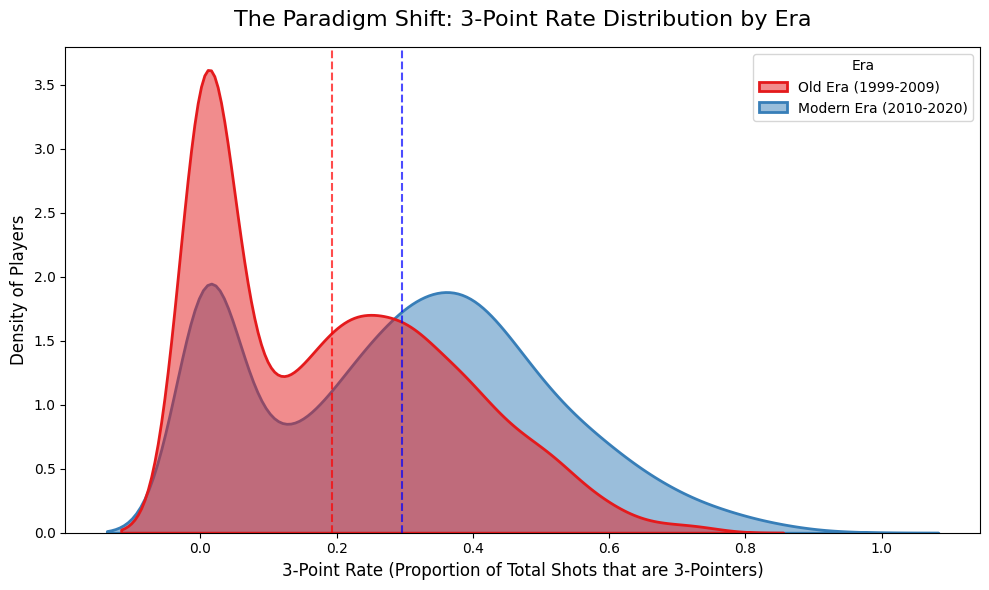

In [ ]:
plt.figure(figsize=(10, 6))

sns.kdeplot(data=df_model, x='3P_Rate', hue='Era',
            fill=True, common_norm=False, palette='Set1', alpha=0.5, linewidth=2)

plt.title('The Paradigm Shift: 3-Point Rate Distribution by Era', pad=15, fontsize=16)
plt.xlabel('3-Point Rate (Proportion of Total Shots that are 3-Pointers)', fontsize=12)
plt.ylabel('Density of Players', fontsize=12)

plt.axvline(df_model[df_model['Era'] == 'Old Era (1999-2009)']['3P_Rate'].mean(), color='red', linestyle='--', alpha=0.7)
plt.axvline(df_model[df_model['Era'] == 'Modern Era (2010-2020)']['3P_Rate'].mean(), color='blue', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

The emergence of 3-point rate as the top feature in the classifier led us to isolate its distribution across two eras. In this visual we can see the shift in the eras. The old era (199-2009) shows a bimodal and left heavy distribution. There is a spike near zero which captures the bigs and traditional post players who almost never attempted threes, with a secondary mode around 0.20 for guards and wings. On the other hand, the Modern Era (2010-2020) distribution is unimodal and shifted right, peaking near 0.35. The near-zero spike has largely collapsed, meaning players who never shoot threes have nearly disappeared from the league. The gap between the means of the two eras shows an increase of around 50% in the number of threes taken across the league.

# **Insights and Conclusions**

Our overarching goal for this project was to analyze how the game of basketball has evolved over the past two decades. Through exploratory data analysis and machine learning, we successfully analyzed how trends for player stats changed from 1999-2009 vs 2010-2020.

An uninformed reader in this scenario might be someone who does not watch basketball. Before reading our analysis, an uninformed reader might see basketball as a static game without much evolution over the years. However, after reading this tutorial, the reader will understand that basketball is dynamic and driven by massive analytical shifts. We demonstrated that a player's statistical output from the early 2000s is very fundamentally different from a player in the late 2010s that a machine learning algorithm can blindly look at their stats and guess which era they played in with roughly 70% accuracy. The uninformed reader can also observe through our analysis the different eras from the 1999-2009 vs 2010-2020 can be heavily dictated by the preference on shooting, and not so much on physical traits like height and weight.

An informed reader in this scenario might be someone who is a passionate basketball fan already knows that the game has changed. They know teams shoot more 3-pointers today than they did in the 2000s. From our analysis, an informed reader might use this data to support their assumption or more qualitative observation of an increase in 3-point shooting with quantitative evidence.

Through our ANOVA testing, they learn that the evolution wasn't a slow, steady climb, but rather a sudden shift that separated the post-2014 era from everything before it.

Through our Random Forest classification, they learn which specific stats define the modern game. It isn't necessarily raw scoring (PPG) that separates the eras, but the proportion of shots taken from beyond the arc (3-Point Rate).

Finally, through our density visualization, the informed reader actually sees the modern era mapped out. They can visually witness how the baseline expectation for 3-point shooting shifted for the entire league, not just for guards.

Ultimately, the data confirms that the NBA has undergone a massive evolution. The traditional mid-range style of the early 2000s has been completely replaced by a highly efficient, perimeter-centric philosophy, emphasizing longer range 3-point shooting. By applying the data science pipeline to two decades of player statistics, we didn't just track the history of basketball—we proved its evolution mathematically.